In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold 
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline 

from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

import joblib



In [2]:
df = pd.read_csv("data/creditcard.csv")
print (df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [3]:
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:


print("Logistic Regression training...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Random Forest training(it may take a while)...")
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n" + "="*40)
print("Logistic Regression results:")
print("="*40)
print(classification_report(y_test, y_pred_lr))

print("\n" + "="*40)
print("Random Forest results:")
print("="*40)
print(classification_report(y_test, y_pred_rf))

Logistic Regression training...
Random Forest training(it may take a while)...

Logistic Regression results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Random Forest results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [19]:
print("Isolation Forest training(looking4anomalies)...")
iso_forest = IsolationForest(n_estimators = 100,
                             contamination = 0.017,
                             random_state = 42,
                             n_jobs = -1)
iso_forest.fit(X_train)
y_pred_iso_raw = iso_forest.predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso_raw]

print("\n" + "="*40)
print("Results - Isolation Forest")
print("="*40)
print(classification_report(y_test, y_pred_iso))

Isolation Forest training(looking4anomalies)...

Results - Isolation Forest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.76      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.87      0.56     56962
weighted avg       1.00      0.98      0.99     56962



In [20]:

print("generating 'false' frauds SMOTE")
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\n2. Training Random Forest on balanced data...")
rf_smote = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)

print("\n" + "="*40)
print("Results - Random Forest + SMOTE")
print("="*40)
print(classification_report(y_test, y_pred_smote))

generating 'false' frauds SMOTE
Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

2. Training Random Forest on balanced data...

Results - Random Forest + SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [7]:

print("Preparing Cross Validation...")

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Testing 5 independent versions...")

scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print("\n" + "="*40)
print("Cross Validation results:")
print("="*40)
print(f"Results from 5 independent versions: {np.round(scores, 3)}")
print(f"Average model accuraccy: {scores.mean():.3f} (+/- {scores.std():.3f})")

Preparing Cross Validation...
Testing 5 independent versions...

Cross Validation results:
Results from 5 independent versions: [0.816 0.819 0.814 0.862 0.853]
Average model accuraccy: 0.833 (+/- 0.021)


In [8]:

y_probs = rf_smote.predict_proba(X_test)[:, 1]

custom_threshold = 0.3
custom_threshold_2 = 0.5
custom_threshold_3 = 0.6
custom_threshold_4 = 0.8


y_pred_custom = (y_probs >= custom_threshold).astype(int)
y_pred_custom_2 = (y_probs >= custom_threshold_2).astype(int)
y_pred_custom_3 = (y_probs >= custom_threshold_3).astype(int)
y_pred_custom_4 = (y_probs >= custom_threshold_4).astype(int)


print(f"Results for accuracy: {custom_threshold}")
print("="*40)
print(classification_report(y_test, y_pred_custom))


print(f"Results for accuracy: {custom_threshold_2}")
print("="*40)
print(classification_report(y_test, y_pred_custom_2))


print(f"Results for accuracy: {custom_threshold_3}")
print("="*40)
print(classification_report(y_test, y_pred_custom_3))

print(f"Results for accuracy: {custom_threshold_4}")
print("="*40)
print(classification_report(y_test,  y_pred_custom_4))

Results for accuracy: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.88      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.94      0.89     56962
weighted avg       1.00      1.00      1.00     56962

Results for accuracy: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Results for accuracy: 0.6
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56

In [9]:

print("1. Training neural network with normal transactions only...")
X_train_normal = X_train[y_train == 0]

X_val_normal = X_train_normal[-10000:] 
X_train_normal = X_train_normal[:-10000]

print("2.Building autoencoder architecture...")
input_dim = X_train.shape[1] 

input_layer = Input(shape=(input_dim,))

encoder = Dense(14, activation="tanh")(input_layer)
encoder = Dense(7, activation="relu")(encoder)

decoder = Dense(14, activation='tanh')(encoder)
decoder = Dense(input_dim, activation='relu')(decoder) 

autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(optimizer='adam', loss='mean_squared_error')

print("\n3. Neural network training...")

history = autoencoder.fit(
    X_train_normal, X_train_normal, 
    epochs=10, 
    batch_size=256,
    validation_data=(X_val_normal, X_val_normal),
    shuffle=True,
    verbose=1
)
print("\nNeual network has been trained")

1. Training neural network with normal transactions only...
2.Building autoencoder architecture...

3. Neural network training...
Epoch 1/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.0946 - val_loss: 0.8622
Epoch 2/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9117 - val_loss: 0.7723
Epoch 3/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8510 - val_loss: 0.7361
Epoch 4/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8208 - val_loss: 0.7171
Epoch 5/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8009 - val_loss: 0.7040
Epoch 6/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7874 - val_loss: 0.6954
Epoch 7/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7774 - val_loss: 0.6900
Epoch 8/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7691 - val_loss: 0.6834
Epoch 9/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7619 - val_loss: 0.6784
Epoch 10/10
850/850 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7563 - val_loss: 0.6745

Neual ne

In [10]:
print("1. Uploading test data to autoencoder...")
reconstructions = autoencoder.predict(X_test)

print("2. Calculating error margin for every transaction...")
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

print("\nReady")

1. Uploading test data to autoencoder...
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
2. Calculating error margin for every transaction...

Ready


In [11]:
print("1. Connecting results with real errors...")
results_ae = pd.DataFrame({'Error_MSE': mse, 'Real_Class': y_test})

print("2. Calculating cut off point...")
threshold = np.percentile(results_ae['Error_MSE'], 99.6)
print(f"Cut-off point: {threshold:.4f}")

print("3. Giving judgements...")
results_ae['Prediction'] = (results_ae['Error_MSE'] >= threshold).astype(int)

print("\n" + "="*40)
print("Results - deep learning")
print("="*40)
print(classification_report(results_ae['Real_Class'], results_ae['Prediction']))

1. Connecting results with real errors...
2. Calculating cut off point...
Cut-off point: 14.2957
3. Giving judgements...

Results - deep learning
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.20      0.46      0.28        98

    accuracy                           1.00     56962
   macro avg       0.60      0.73      0.64     56962
weighted avg       1.00      1.00      1.00     56962



Generating reconstruction error plot...


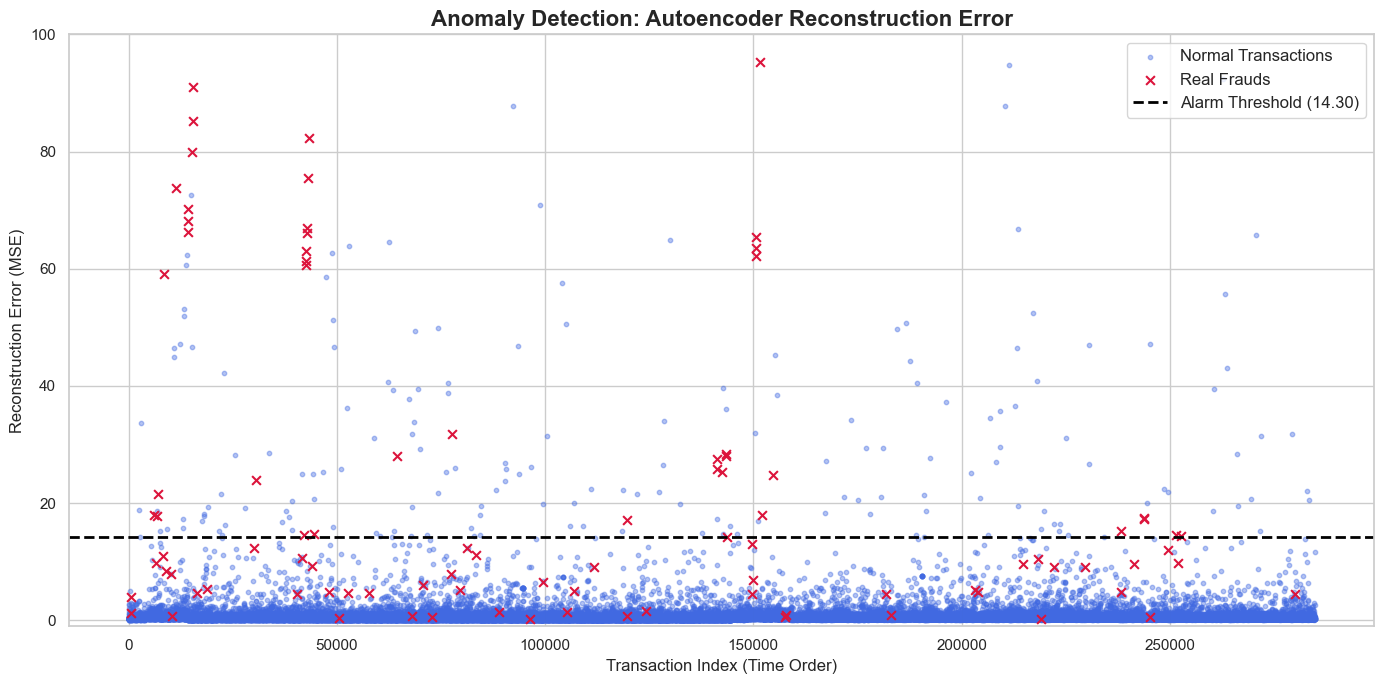

In [17]:
print("Generating reconstruction error plot...")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

normal_transactions = results_ae[results_ae['Real_Class'] == 0]
fraud_transactions = results_ae[results_ae['Real_Class'] == 1]

plt.scatter(normal_transactions.index, normal_transactions['Error_MSE'], 
            color='royalblue', s=10, alpha=0.4, label='Normal Transactions')

plt.scatter(fraud_transactions.index, fraud_transactions['Error_MSE'], 
            color='crimson', s=40, marker='x', label='Real Frauds')

plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2, 
            label=f'Alarm Threshold ({threshold:.2f})')

plt.ylim(-1, 100) 

plt.title('Anomaly Detection: Autoencoder Reconstruction Error', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Index (Time Order)', fontsize=12)
plt.ylabel('Reconstruction Error (MSE)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.savefig('autoencoder_anomalies.png', dpi=300, bbox_inches='tight')
plt.show()

Generating the final Confusion Matrix for Random Forest...


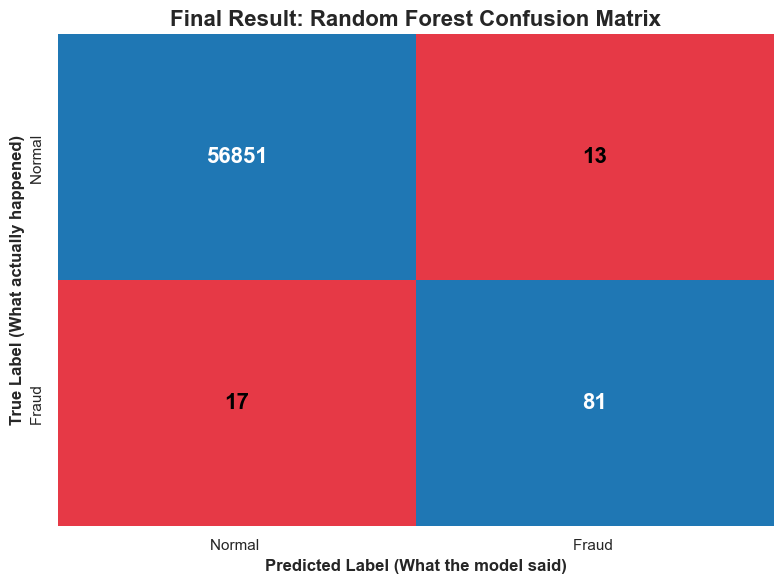

In [16]:
print("Generating the final Confusion Matrix for Random Forest...")

y_pred_rf = rf_smote.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

mask_correct = np.array([[False, True], 
                         [True, False]])

mask_errors = np.array([[True, False], 
                        [False, True]])

solid_blue = ListedColormap(['#1f77b4'])  
light_red = ListedColormap(['#e63946'])

plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap=solid_blue, 
            mask=mask_correct, cbar=False,
            xticklabels=['Normal ', 'Fraud'], 
            yticklabels=['Normal ', 'Fraud '],
            annot_kws={"size": 16, "weight": "bold", "color": "white"})

sns.heatmap(cm, annot=True, fmt='d', cmap=light_red, 
            mask=mask_errors, cbar=False,
            xticklabels=['Normal ', 'Fraud '], 
            yticklabels=['Normal ', 'Fraud '],
            annot_kws={"size": 16, "weight": "bold", "color": "black"})

plt.title('Final Result: Random Forest Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label (What the model said)', fontsize=12, fontweight='bold')
plt.ylabel('True Label (What actually happened)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
joblib.dump(rf_smote, 'fraud_model_rf.pkl')
print("Model saved successfully!")

Model saved successfully!
